We wcześniejszych notatnikach działałem na RandomForestRegressor/Classifier, była to metoda lasu losowego, która polega na uśrednieniu prognozy wielu drzew decyzyjnych.Metodę lasu losowego nazywamy „metodą zespołową (ensemble method)”. Z definicji metody zespołowe łączą prognozy kilku modeli (np. kilku drzew w przypadku lasów losowych).Dzisiaj nauczę się następnej "metody zespołowej" jaką jest wzmacnianie gradientowe.XGBoost działa inaczej niż Las Losowy – buduje drzewa sekwencyjnie (jedno po drugim), gdzie każde kolejne drzewo skupia się na poprawianiu błędów popełnionych przez poprzednie. Dzięki temu potrafi wyłapać subtelne i trudne wzorce w skomplikowanych danych molekularnych. Porównam go z RandomForest.
https://www.kaggle.com/code/alexisbcook/xgboost

Zaczynam od wczytania potrzebnych nam bibliotek. Tutaj nowością XGBClassifier:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

Dodaje dane (korzystam z tych samych co w poprzednich dniach)

In [10]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz"
df = pd.read_csv(url)
df = df.dropna(subset=['smiles', 'CT_TOX']) #dropna(subset...) oznacza że jeśli w bazie trafi się wiersz który nie ma zapisanego smiles albo brakuje CT_TOX to go wyrzuca

In [ ]:
Uzyskywanie Fingerprintów:

In [12]:
X_lista = [] #Tu zbieram fingerprinty (wektory)
valid_indices = [] #Tu zbieram poprawne wierszy

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

for idx, sml in enumerate(df['smiles']): #Wyciągam smiles i pozycję w tabeli
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol)
        bit_string = fp.ToBitString() #Wektor zamieniam na string
        bit_vector = [int(bit) for bit in bit_string]
        X_lista.append(bit_vector)
        valid_indices.append(idx)

[00:12:40] Explicit valence for atom # 0 N, 4, is greater than permitted
[00:12:40] Can't kekulize mol.  Unkekulized atoms: 9
[00:12:40] Can't kekulize mol.  Unkekulized atoms: 4
[00:12:40] Can't kekulize mol.  Unkekulized atoms: 4


Bezpieczna synchronizacja:

In [13]:
df_clean = df.iloc[valid_indices].reset_index(drop=True) #Tworzenie czystej tabeli z poprawnymi wierszami
X = np.array(X_lista)
Y = df_clean["CT_TOX"].values

Podział na trening i test:

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
 #stratify = pilnuje, aby unikalne proporcje zostały po równo zachowane w obu zbiorach.
neg_count = (Y_train == 0).sum()
pos_count = (Y_train == 1).sum()
skala_wag= neg_count / pos_count #mnożnik kary który nałożymy na algorytm
print("Związki toksyczne w trenowanych:", pos_count)
print("Związki bezpieczne w trenowanych:", neg_count)

Związki toksyczne w trenowanych: 90
Związki bezpieczne w trenowanych: 1094


Trenowanie modelu:

In [ ]:
model_xgb = XGBClassifier(
    scale_pos_weight=skala_wag,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    max_depth=2,
    eval_metric="logloss"
)
model_xgb.fit(X_train, Y_train)

Wyskoczyła śmieszna wizytówka modelu, która nie pokaże sie na githubie, bardzo fajny gadżet.
Czas na próg decyzyjny. Zamiast strzału 0 albo 1, wyciągam precyzyjne odczyty prawdopodobieństwa i bierzemy tylko kolumne numer 1 (szansa na bycie trucizna). Ustalam rygor na 30% każdy wynik równy lub wyższy 30% ulega zamianie na 1 za pomocą astype(int)

In [74]:
prawdopodobienstwo = model_xgb.predict_proba(X_test)
szansa_toksycznosci = prawdopodobienstwo[:, 1]
nowy_prog = 0.30
Y_pred_xgb = (szansa_toksycznosci >= nowy_prog).astype(int)


Graficzne zestawienie macierzy:

T: 22
B: 274


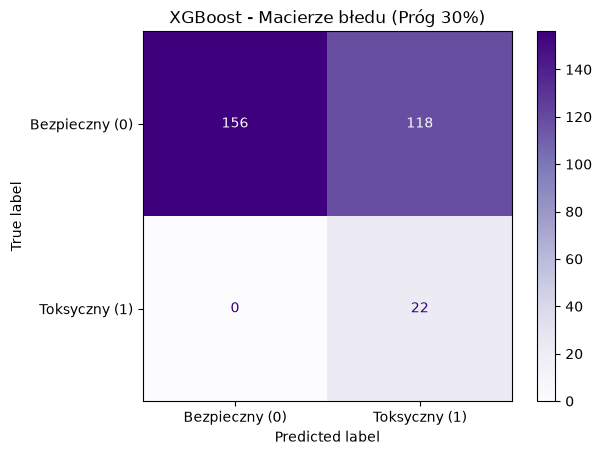

In [75]:
cm = confusion_matrix(Y_test, Y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bezpieczny (0)", "Toksyczny (1)"])
disp.plot(cmap=plt.cm.Purples)
plt.title(f"XGBoost - Macierze błedu (Próg {int(nowy_prog*100)}%)")
plt.show

toksyny_w_test = np.sum(Y_test==1)
bezpieczne_w_test = np.sum(Y_test==0)
print("T:", toksyny_w_test)
print("B:", bezpieczne_w_test)

Wnioski dopisze rano ;)